# Carrera de Obstáculos con Aprendizaje por Refuerzo

Un agente debe aprender a recorrer una cuadrícula desde la esquina superior izquierda
hasta la esquina inferior derecha, esquivando obstáculos (paredes).

```
 A .  #  .  .  .       A = Agente (inicio)
 .  #  .  .  #  .       M = Meta (final)
 .  .  .  #  .  .       # = Pared (no se puede pasar)
 .  #  .  .  .  #       . = Camino libre
 #  .  .  #  .  .
 .  .  #  .  .  M
```

El agente puede moverse en 4 direcciones: arriba, abajo, izquierda, derecha.
Los obstáculos actúan como **paredes**: el agente solo puede moverse a celdas libres.

### Estrategia de exploración/explotación: UCB (Upper Confidence Bound)

Usamos **Selección de acciones con intervalo de confianza (UCB)**.
La fórmula UCB selecciona la acción que maximiza:

$$A_t = \arg\max_a \left[ Q(s,a) + c \sqrt{\frac{\ln t}{N(s,a)}} \right]$$

Donde:
- $Q(s,a)$ = valor estimado de tomar la acción $a$ en el estado $s$
- $c$ = parámetro de exploración (controla cuánto exploramos)
- $t$ = número total de veces que hemos visitado el estado $s$
- $N(s,a)$ = número de veces que hemos tomado la acción $a$ en el estado $s$
- $\sqrt{\frac{\ln t}{N(s,a)}}$ = **intervalo de confianza**: es grande cuando la acción se ha probado poco

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import math

## Board: la cuadrícula con obstáculos (Entorno)

La cuadrícula es de `ROWS x COLS`. Los obstáculos actúan como paredes:
el agente **no puede** moverse hacia una celda con obstáculo.

- `valid_moves()`: devuelve las direcciones que llevan a celdas libres (sin salir del tablero y sin obstáculos)
- `update(action)`: mueve al agente en la dirección indicada
- `is_game_over()`: 1 si llegó a la meta, 0 si agotó pasos, None si sigue

In [2]:
ROWS = 6
COLS = 6
START = (0, 0)          # esquina superior izquierda
GOAL = (ROWS-1, COLS-1) # esquina inferior derecha
MAX_STEPS = 50          # máximo de pasos por episodio

# Mapa de obstáculos: 1 = pared, 0 = libre
OBSTACLES = np.array([
    [0, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 1],
    [1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0],
])

# Direcciones: (delta_row, delta_col)
ACCIONES = {
    'arriba':    (-1, 0),
    'abajo':     ( 1, 0),
    'izquierda': ( 0,-1),
    'derecha':   ( 0, 1),
}


class Board():
    def __init__(self):
        self.state = OBSTACLES.copy()
        self.pos = START
        self.steps = 0

    def valid_moves(self):
        """Devuelve acciones que no salen del tablero y no llevan a obstáculo."""
        moves = []
        for nombre, (dr, dc) in ACCIONES.items():
            nr, nc = self.pos[0] + dr, self.pos[1] + dc
            if 0 <= nr < ROWS and 0 <= nc < COLS and self.state[nr, nc] == 0:
                moves.append(nombre)
        return moves

    def update(self, symbol, action):
        """Mueve al agente en la dirección indicada."""
        dr, dc = ACCIONES[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc
        self.pos = (nr, nc)
        self.steps += 1

    def is_game_over(self):
        # llegó a la meta
        if self.pos == GOAL:
            return 1
        # agotó los pasos
        if self.steps >= MAX_STEPS:
            return 0
        # seguir jugando
        return None

    def reset(self):
        self.state = OBSTACLES.copy()
        self.pos = START
        self.steps = 0

## Game: ejecuta episodios de entrenamiento

En cada episodio el agente se mueve hasta llegar a la meta o agotar pasos.
Al final se le da la recompensa y el agente propaga el valor hacia atrás.

In [3]:
class Game():
    def __init__(self, player1):
        player1.symbol = 1
        self.players = [player1]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0]
        for i in range(1, rounds + 1):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action)
                    for player in self.players:
                        player.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            self.reward()
            if self.board.is_game_over() == 1:
                wins[0] += 1
        return wins

    def reward(self):
        result = self.board.is_game_over()
        if result == 1:  # llegó a la meta
            for player in self.players:
                player.reward(1)
        else:  # agotó pasos
            for player in self.players:
                player.reward(0)

## Agent con UCB (Selección con Intervalo de Confianza)

La diferencia clave con ε-greedy es el método `move()`:

**ε-greedy (tres en raya):**
```python
if random < prob_exp:
    acción aleatoria       # exploración ciega
else:
    acción con mayor Q     # explotación pura
```

**UCB (este cuadernillo):**
```python
acción = argmax[ Q(s,a) + c * sqrt(ln(t) / N(s,a)) ]
```

No hay exploración al azar. El agente **siempre** elige la mejor acción,
pero "mejor" incluye un bonus para acciones poco probadas.
La exploración es **dirigida**, no ciega.

In [4]:
class Agent():
    def __init__(self, alpha=0.5, c=2.0):
        self.value_function = {} # tabla estado -> valor V(s)
        self.Q = {}              # tabla (estado, accion) -> valor Q(s,a)
        self.N = {}              # tabla (estado, accion) -> conteo N(s,a)
        self.N_state = {}        # tabla estado -> conteo total t
        self.alpha = alpha       # learning rate
        self.c = c               # parámetro de exploración UCB
        self.positions = []      # estados visitados en el episodio

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        estado = str(board.pos)

        # incrementar contador del estado
        if self.N_state.get(estado) is None:
            self.N_state[estado] = 0
        self.N_state[estado] += 1
        t = self.N_state[estado]

        if not explore:
            # inferencia: greedy puro (sin bonus UCB)
            max_value = -1000
            best_action = valid_moves[0]
            for action in valid_moves:
                q_val = self.Q.get((estado, action), 0)
                if q_val >= max_value:
                    max_value = q_val
                    best_action = action
            return best_action

        # === UCB: selección con intervalo de confianza ===
        max_ucb = -1000
        best_action = valid_moves[0]
        for action in valid_moves:
            q_val = self.Q.get((estado, action), 0)
            n_sa = self.N.get((estado, action), 0)

            if n_sa == 0:
                # acción nunca probada → bonus infinito → se elige primero
                ucb_val = 1000
            else:
                # fórmula UCB: Q(s,a) + c * sqrt(ln(t) / N(s,a))
                ucb_val = q_val + self.c * math.sqrt(math.log(t) / n_sa)

            if ucb_val >= max_ucb:
                max_ucb = ucb_val
                best_action = action

        # incrementar contador de la acción elegida
        key = (estado, best_action)
        if self.N.get(key) is None:
            self.N[key] = 0
        self.N[key] += 1

        return best_action

    def update(self, board):
        self.positions.append(str(board.pos))

    def reward(self, reward):
        # propagación hacia atrás (misma fórmula del curso)
        # V(St) <- V(St) + alpha * [V(St+1) - V(St)]
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

        # actualizar Q(s,a) con el valor del estado siguiente
        for idx in range(len(self.positions) - 1):
            s = self.positions[idx]
            s_next = self.positions[idx + 1]
            pos_actual = eval(s)
            pos_sig = eval(s_next)
            dr = pos_sig[0] - pos_actual[0]
            dc = pos_sig[1] - pos_actual[1]
            accion = None
            for nombre, (d_r, d_c) in ACCIONES.items():
                if d_r == dr and d_c == dc:
                    accion = nombre
                    break
            if accion is not None:
                key = (s, accion)
                if self.Q.get(key) is None:
                    self.Q[key] = 0
                v_next = self.value_function.get(s_next, 0)
                self.Q[key] += self.alpha * (v_next - self.Q[key])

## Entrenamiento

Entrenamos con 100,000 episodios. El parámetro `c=2.0` controla la exploración UCB.

In [5]:
agent1 = Agent(alpha=0.5, c=2.0)

game = Game(agent1)
wins = game.selfplay(100000)

print(f'Veces que llegó a la meta: {wins[0]} / 100000')
print(f'Estados aprendidos (V): {len(agent1.value_function)}')
print(f'Pares (estado, acción) aprendidos (Q): {len(agent1.Q)}')

Veces que llegó a la meta: 96214 / 100000
Estados aprendidos (V): 27
Pares (estado, acción) aprendidos (Q): 54


## Función de valor

In [6]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,"(4, 4)",1.000000e+00
1,"(3, 4)",1.000000e+00
2,"(3, 3)",1.000000e+00
3,"(3, 2)",1.000000e+00
4,"(2, 2)",1.000000e+00
5,"(2, 1)",1.000000e+00
6,"(2, 0)",1.000000e+00
7,"(1, 0)",1.000000e+00
8,"(5, 5)",1.000000e+00
9,"(5, 4)",1.000000e+00


### Curva de aprendizaje

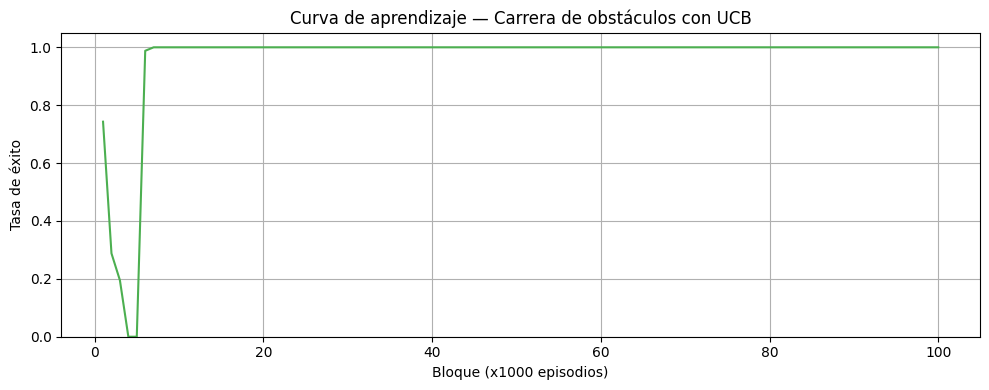

In [10]:
agent_curva = Agent(alpha=0.5, c=2.0)
game_curva = Game(agent_curva)

total_eps = 100000
bloque = 1000
exitos = []

for b in range(total_eps // bloque):
    w = game_curva.selfplay(bloque)
    exitos.append(w[0] / bloque)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(exitos)+1), exitos, color='#4CAF50')
plt.xlabel('Bloque (x1000 episodios)')
plt.ylabel('Tasa de éxito')
plt.title('Curva de aprendizaje — Carrera de obstáculos con UCB')
plt.grid(True)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Comparación UCB con diferentes valores de c

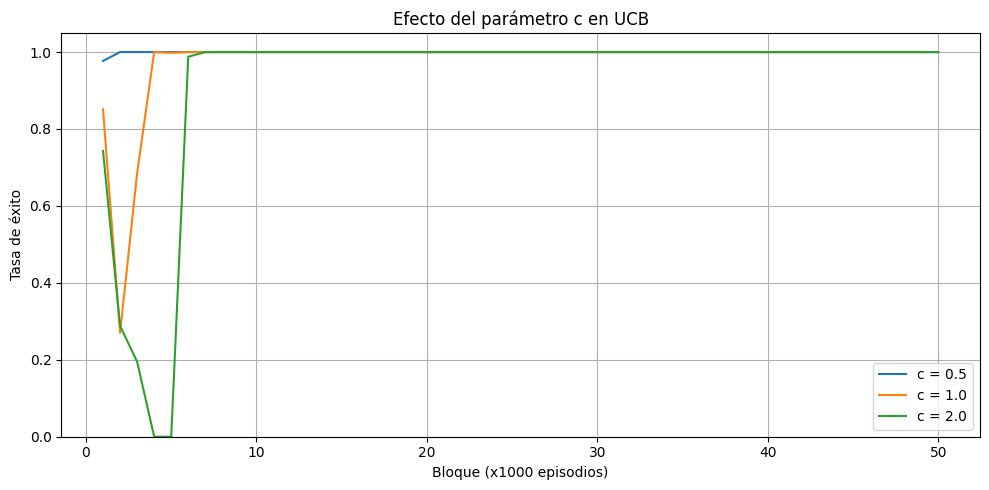

In [11]:
valores_c = [0.5, 1.0, 2.0]
total_eps = 50000
bloque = 1000

plt.figure(figsize=(10, 5))
for c_val in valores_c:
    agent_c = Agent(alpha=0.5, c=c_val)
    game_c = Game(agent_c)
    exitos_c = []
    for b in range(total_eps // bloque):
        w = game_c.selfplay(bloque)
        exitos_c.append(w[0] / bloque)
    plt.plot(range(1, len(exitos_c)+1), exitos_c, label=f'c = {c_val}')

plt.xlabel('Bloque (x1000 episodios)')
plt.ylabel('Tasa de éxito')
plt.title('Efecto del parámetro c en UCB')
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [12]:
with open('agente_obstaculos_ucb.pickle', 'wb') as handle:
    pickle.dump({
        'value_function': agent1.value_function,
        'Q': agent1.Q,
        'N': agent1.N,
        'N_state': agent1.N_state,
    }, handle, protocol=pickle.HIGHEST_PROTOCOL)

print('Agente guardado correctamente.')

Agente guardado correctamente.


## Jugar: ver al agente recorrer la pista

In [13]:
class AgentInferencia:
    def __init__(self, Q_table, symbol=1):
        self.Q = Q_table
        self.symbol = symbol

    def move(self, board):
        valid_moves = board.valid_moves()
        estado = str(board.pos)
        max_value = -1000
        best_action = valid_moves[0]
        for action in valid_moves:
            q_val = self.Q.get((estado, action), 0)
            if q_val >= max_value:
                max_value = q_val
                best_action = action
        return best_action


def dibujar_tablero(board):
    simbolos = {0: '.', 1: '#'}
    print('')
    for r in range(ROWS):
        fila = []
        for c in range(COLS):
            if (r, c) == board.pos:
                fila.append(' A')
            elif (r, c) == GOAL:
                fila.append(' M')
            else:
                fila.append(' ' + simbolos[int(board.state[r, c])])
        print(' '.join(fila))
    print(f'Paso {board.steps} — Posición: {board.pos}')
    print('')


def jugar():
    board = Board()
    agente = AgentInferencia(agent1.Q)

    print(f'Cuadrícula {ROWS}x{COLS} — A=Agente, M=Meta, #=Pared')
    print('Estrategia: UCB (greedy sobre Q(s,a) aprendido)')
    dibujar_tablero(board)

    while board.is_game_over() is None:
        action = agente.move(board)
        board.update(1, action)
        print(f'Agente se mueve: {action}')
        dibujar_tablero(board)

    resultado = board.is_game_over()
    if resultado == 1:
        print(f'¡Llegó a la meta en {board.steps} pasos!')
    else:
        print('Agotó los pasos sin llegar.')

In [14]:
jugar()

Cuadrícula 6x6 — A=Agente, M=Meta, #=Pared
Estrategia: UCB (greedy sobre Q(s,a) aprendido)

 A  .  #  .  .  .
 .  #  .  .  #  .
 .  .  .  #  .  .
 .  #  .  .  .  #
 #  .  .  #  .  .
 .  .  #  .  .  M
Paso 0 — Posición: (0, 0)

Agente se mueve: abajo

 .  .  #  .  .  .
 A  #  .  .  #  .
 .  .  .  #  .  .
 .  #  .  .  .  #
 #  .  .  #  .  .
 .  .  #  .  .  M
Paso 1 — Posición: (1, 0)

Agente se mueve: abajo

 .  .  #  .  .  .
 .  #  .  .  #  .
 A  .  .  #  .  .
 .  #  .  .  .  #
 #  .  .  #  .  .
 .  .  #  .  .  M
Paso 2 — Posición: (2, 0)

Agente se mueve: derecha

 .  .  #  .  .  .
 .  #  .  .  #  .
 .  A  .  #  .  .
 .  #  .  .  .  #
 #  .  .  #  .  .
 .  .  #  .  .  M
Paso 3 — Posición: (2, 1)

Agente se mueve: derecha

 .  .  #  .  .  .
 .  #  .  .  #  .
 .  .  A  #  .  .
 .  #  .  .  .  #
 #  .  .  #  .  .
 .  .  #  .  .  M
Paso 4 — Posición: (2, 2)

Agente se mueve: abajo

 .  .  #  .  .  .
 .  #  .  .  #  .
 .  .  .  #  .  .
 .  #  A  .  .  #
 #  .  .  #  .  .
 .  .  #  .  .  M
P